Today we do the multiclass Classification on Logistic Regression 

In [17]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

# 1D decesion bounday 

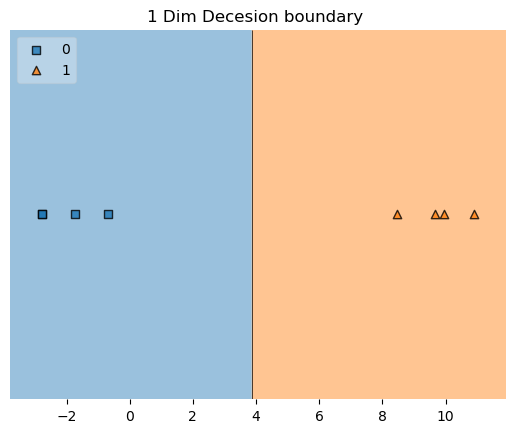

In [18]:

# 1. Generate a synthetic 2D dataset with 2 classes
X, y = make_blobs(n_samples=8, n_features=1, centers=2, random_state=42 , cluster_std=1.2)

# 2. Fit the Logistic Regression model
model = LogisticRegression()
model.fit(X, y)

plot_decision_regions(X, y, clf=model, legend=2)
#plt.xlabel('feature1')
plt.title('1 Dim Decesion boundary ')
plt.show()

# 2D decesion bounday 

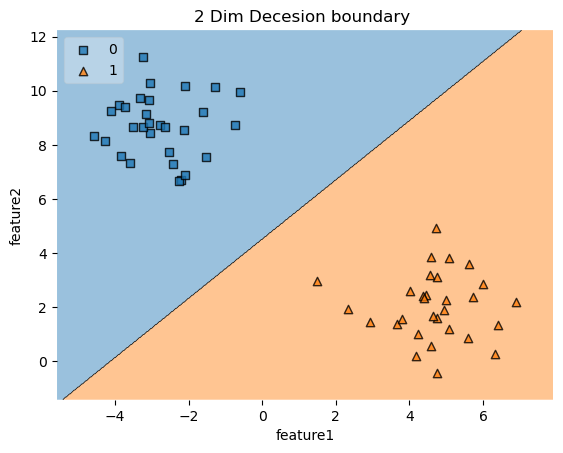

In [19]:

# 1. Generate a synthetic 2D dataset with 2 classes
X, y = make_blobs(n_samples=60, centers=2, random_state=42, cluster_std=1.2)

# 2. Fit the Logistic Regression model
model = LogisticRegression()
model.fit(X, y)

plot_decision_regions(X, y, clf=model, legend=2)
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.title('2 Dim Decesion boundary ')
plt.show()

# OVR

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix


In [21]:
df = sns.load_dataset('iris')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [22]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In iris dataset we have 3 categoris

In [23]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

In [24]:
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
44,5.1,3.8,1.9,0.4,0
48,5.3,3.7,1.5,0.2,0
39,5.1,3.4,1.5,0.2,0
60,5.0,2.0,3.5,1.0,1
55,5.7,2.8,4.5,1.3,1


In [25]:
simple_df = df[['sepal_length','petal_length','species']]
simple_df

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0
...,...,...,...
145,6.7,5.2,2
146,6.3,5.0,2
147,6.5,5.2,2
148,6.2,5.4,2


In [26]:
X = simple_df.iloc[:,0:2]
y = simple_df.iloc[:,-1]

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [28]:
clf = LogisticRegression(multi_class='ovr')
clf.fit(X_train,y_train)

c:\Users\sumit\miniconda3\envs\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr')

In [29]:
y_pred = clf.predict(X_test)

print(accuracy_score(y_test,y_pred))

0.9666666666666667


In [30]:
pd.DataFrame(confusion_matrix(y_test,y_pred))

,0,1,2
0,14,0,0
1,0,7,1
2,0,0,8


In [31]:
# prediction
query = np.array([[3.4,2.7]])
clf.predict_proba(query)
# we get proability of each class 

c:\Users\sumit\miniconda3\envs\my_env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.44391859, 0.55507579, 0.00100562]])

In [32]:
clf.predict(query)

c:\Users\sumit\miniconda3\envs\my_env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

c:\Users\sumit\miniconda3\envs\my_env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


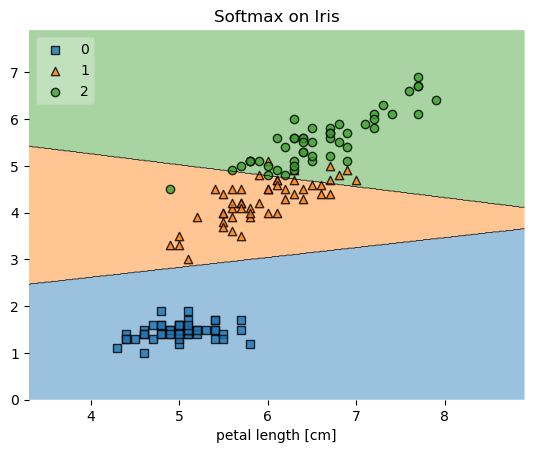

In [33]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X.values, y.values, clf, legend=2)

# Adding axes annotations
plt.xlabel('sepal length [cm]')
plt.xlabel('petal length [cm]')
plt.title('Softmax on Iris')

plt.show()

# Multinomial

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.datasets import load_iris


In [35]:
X = load_iris()['data'][:,0::2]
y = load_iris()['target']

In [40]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


clf = LogisticRegression(multi_class='multinomial')
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

print(accuracy_score(y_test,y_pred))


0.9666666666666667


c:\Users\sumit\miniconda3\envs\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [37]:
pd.DataFrame(confusion_matrix(y_test,y_pred))

,0,1,2
0,14,0,0
1,0,7,1
2,0,0,8


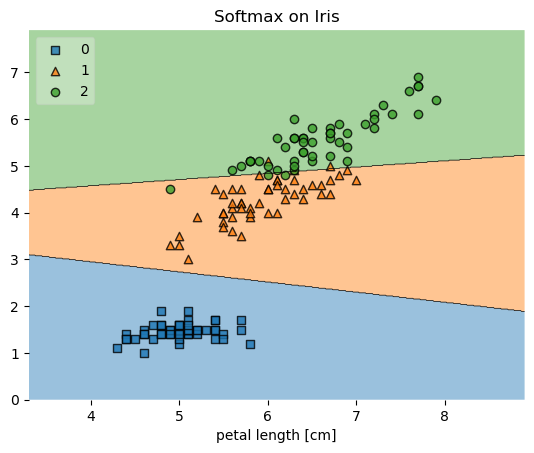

In [41]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X,y, clf, legend=2)

# Adding axes annotations
plt.xlabel('sepal length [cm]')
plt.xlabel('petal length [cm]')
plt.title('Softmax on Iris')

plt.show()